#### 第五次作業：混合常態分配參數估計：參數、樣本量影響分析與兩種 MLE 方法（optimize.minimize 與 GaussianMixture）之比較
姓名：陳維萱</font>

學號：411180015</font>

作品目標：此作品探討混合常態分配在不同參數下對 PDF 圖形的影響，並進行參數估計實驗，探討樣本數大小對估計準確性的影響。通過 Monte Carlo 模擬，對比兩種估計方法（optimize.minimize 和 GaussianMixture），分析估計值的平均數（Mean）、偏差（Bias）及均方根誤差（RMSE），以評估各方法在不同情境下的準確性與穩定性。






<hr>
<font color=#EF9520> （一）不同參數下混合常態分配PDF圖形比較 </font>

- 本實驗旨在研究混合正態分布模型中不同參數組合對分布形狀的影響。自行設定資料生成的參數 $\Omega$ = $\{\pi_1,\mu_1,\sigma_1^2, \mu_2,\sigma_2^2\}$，生成不同的資料分布，並繪製對應的概率密度函數 (PDF)。
- 六組參數分別為：

  1. $\Omega_1$ = $\{ \pi_1 = 0.5, \mu_1 = 0, \sigma_1^2 = 1, \mu_2 = 1, \sigma_2^2 = 1 \}$
  2. $\Omega_2$ = $\{ \pi_1 = 0.5, \mu_1 = 0, \sigma_1^2 = 1, \mu_2 = 2, \sigma_2^2 = 0.5 \}$
  3. $\Omega_3$ = $\{ \pi_1 = 0.7, \mu_1 = 0.8, \sigma_1^2 = 0.2, \mu_2 = 0.8, \sigma_2^2 = 1 \}$
  4. $\Omega_4$ = $\{ \pi_1 = 0.7, \mu_1 = 0, \sigma_1^2 = 1, \mu_2 = 3.5, \sigma_2^2 = 2 \}$
  5. $\Omega_5$ = $\{ \pi_1 = 0.9, \mu_1 = 0, \sigma_1^2 = 0.8, \mu_2 = 2.5, \sigma_2^2 = 0.2 \}$
  6. $\Omega_6$ = $\{ \pi_1 = 0.4, \mu_1 = 0, \sigma_1^2 = 1, \mu_2 = 5, \sigma_2^2 = 1.5 \}$

<hr>

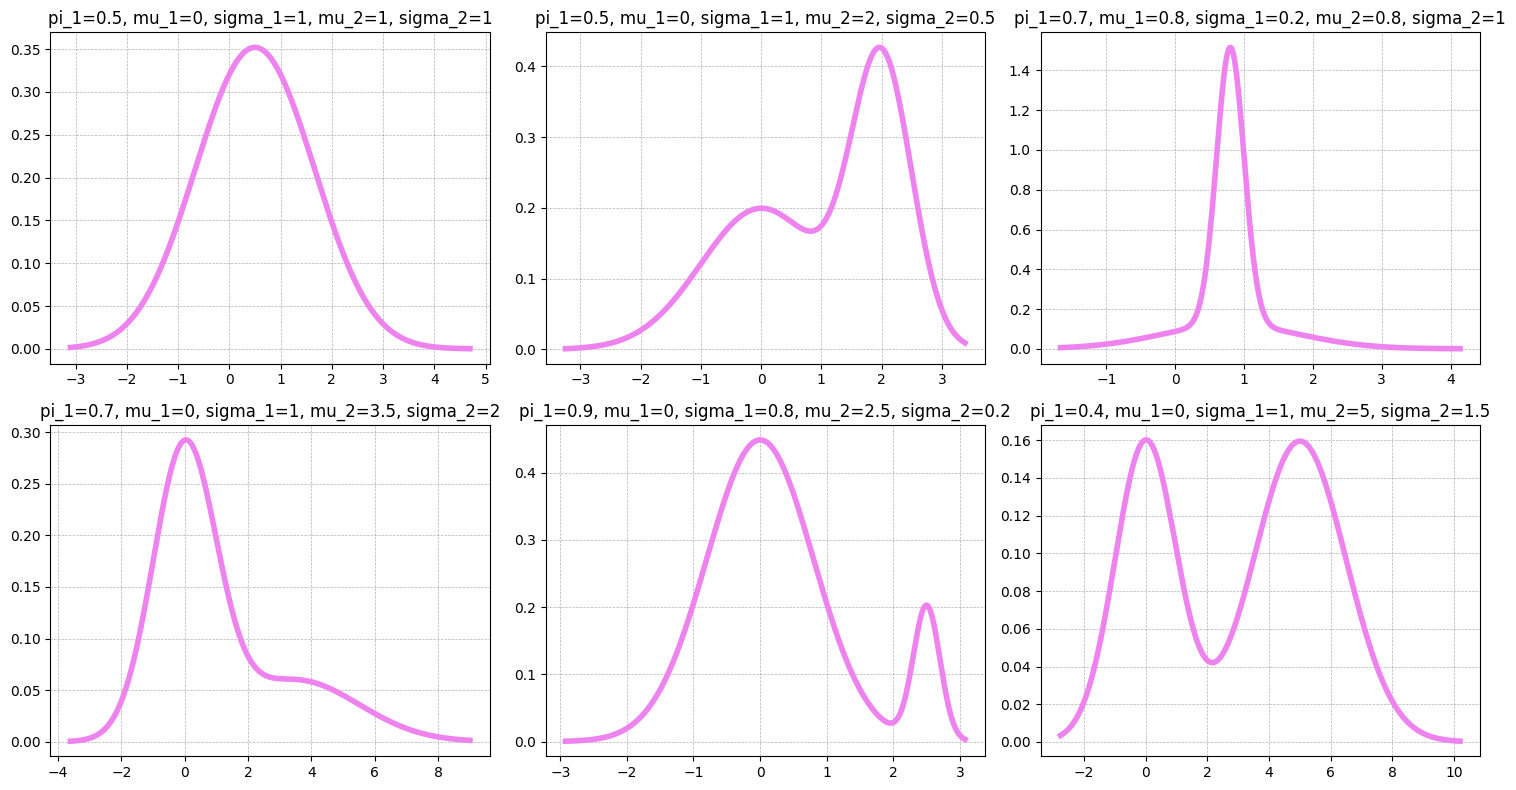

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 設定資料生成的參數
params = [
    {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 1, 'sigma_2': 1},
    {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5},
    {'pi_1': 0.7, 'mu_1': 0.8, 'sigma_1': 0.2, 'mu_2': 0.8, 'sigma_2': 1},
    {'pi_1': 0.7, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 3.5, 'sigma_2': 2},
    {'pi_1': 0.9, 'mu_1': 0, 'sigma_1': 0.8, 'mu_2': 2.5, 'sigma_2': 0.2},
    {'pi_1': 0.4, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 5, 'sigma_2': 1.5}
]

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size=1000):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, param in enumerate(params):
    data = generate_data(**param)
    ax = axs[i // 3, i % 3]
    
    # 繪製 PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf1 = param['pi_1'] * norm.pdf(x, param['mu_1'], param['sigma_1'])
    pdf2 = (1 - param['pi_1']) * norm.pdf(x, param['mu_2'], param['sigma_2'])
    ax.plot(x, pdf1 + pdf2, 'violet', linewidth=4)
    ax.grid(True, linestyle='--', alpha=0.6, color='gray', linewidth=0.5)
    
    ax.set_title(f"pi_1={param['pi_1']}, mu_1={param['mu_1']}, sigma_1={param['sigma_1']}, mu_2={param['mu_2']}, sigma_2={param['sigma_2']}")

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- $pi_1$ 決定了分佈的相對影響力，當 $pi_1$ 越接近 1，第一個分佈對總體分佈的影響越大，第二個分佈的影響減弱，整體圖形更接近第一個分佈；當 $pi_1$ 接近 0.5，兩個分佈的影響相近，圖形呈現更對稱或均衡的特性。
>- $mu$ 控制了分佈的位置，當兩個分佈的均值接近時，圖形可能呈現單峰，或出現重疊的寬峰分佈，而當均值差距較大時，兩個分佈在圖形上形成明顯的雙峰，甚至完全分離。
>- $sigma$ 決定了分佈的形狀與寬度，標準差小的分佈呈現窄而陡的峰值，對應範圍內的數據密度高；標準差大的分佈較為平坦，影響範圍廣，對尾部的分佈影響更顯著，當兩個分佈的標準差差異很大時，小標準差的分佈在圖中形成尖峰，而大標準差的分佈更加平滑。


<hr>
<font color=#EF9520> （二）不同樣本數下混合常態分配估計比較 </font>

- 本實驗探討不同樣本數下（n= 50, 100, 300, 500, 1000, 2000），對估計的精確度影響，並比較兩種估計法，(optimize.minimize)及（EM 算法，GaussianMixture）。過實驗生成混合分佈數據，對比兩種方法在樣本量不同的情況下對模型參數的估計效果，並通過 PDF 圖形比較其逼近真實分佈的準確性。

<hr>

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_41012/3436089927.py:26: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(likelihood))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


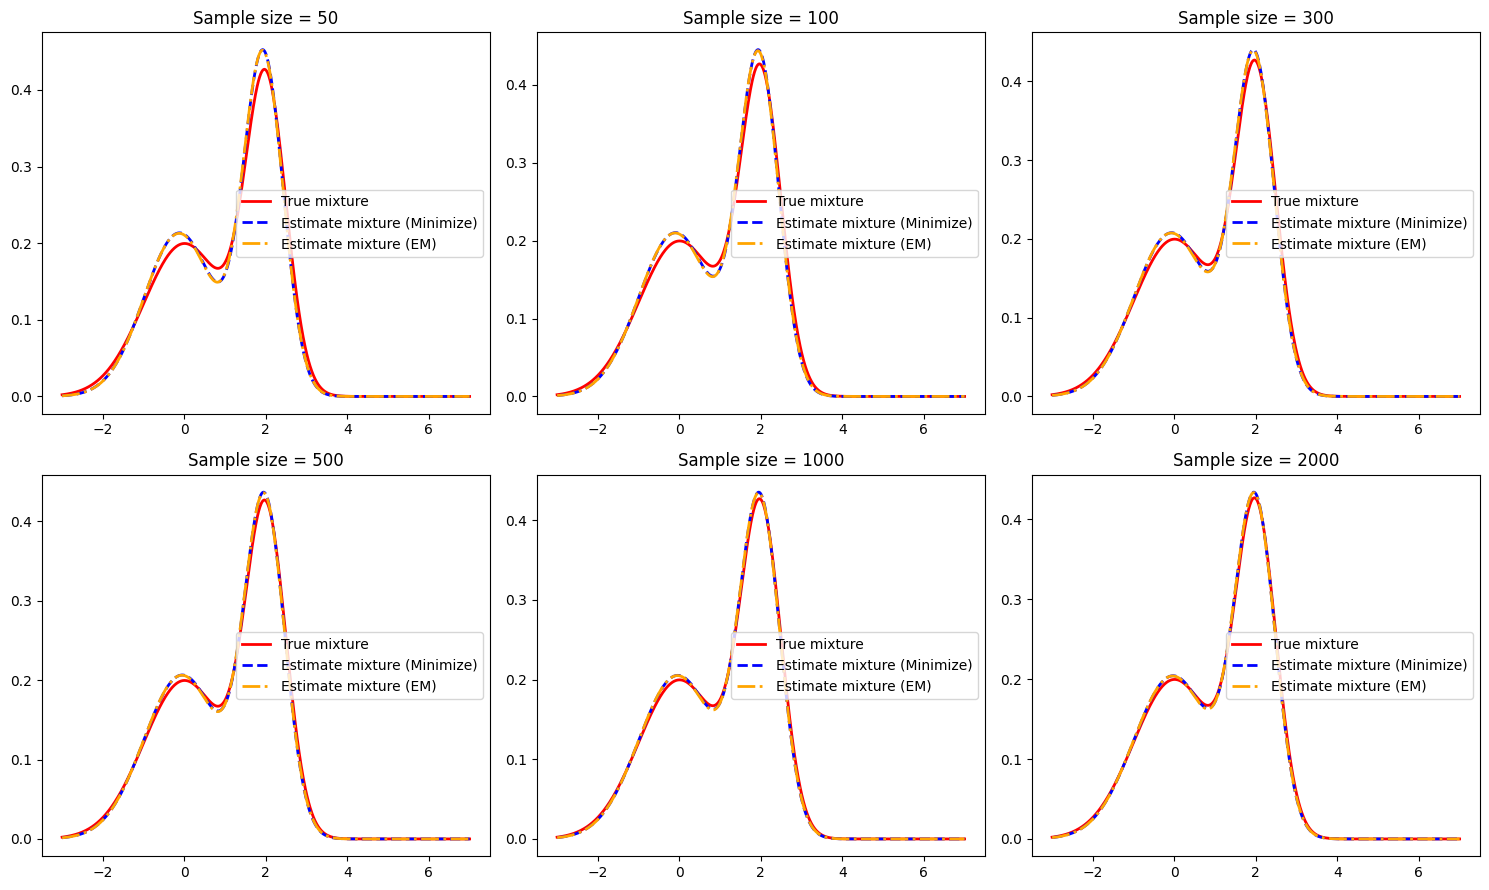

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 100  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    return -np.sum(np.log(likelihood))

# 儲存結果
results_minimize = {param: [] for param in true_params}
results_em = {param: [] for param in true_params}

# 繪製子圖
fig, axs = plt.subplots(2, 3, figsize=(15, 9))

# 進行實驗
for i, n in enumerate(n_values):
    for _ in range(N):
        data = generate_data(**true_params, size=n)
        
        # 使用 optimize.minimize 進行參數估計
        initial_params = [0.5, 0, 1, 2, 0.5]
        bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)]
        result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
        if result.success:
            pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
            results_minimize['pi_1'].append(pi_1_min)
            results_minimize['mu_1'].append(mu_1_min)
            results_minimize['sigma_1'].append(sigma_1_min)
            results_minimize['mu_2'].append(mu_2_min)
            results_minimize['sigma_2'].append(sigma_2_min)
        
        # 使用 sklearn.mixture.GaussianMixture 進行參數估計
        gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000,
                              weights_init=[0.5, 0.5],
                              means_init=np.array([0, 2]).reshape(2, 1))
        gmm.fit(data.reshape(-1, 1))
        pi_1_em = gmm.weights_[0]
        mu_1_em, mu_2_em = gmm.means_.flatten()
        sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
        results_em['pi_1'].append(pi_1_em)
        results_em['mu_1'].append(mu_1_em)
        results_em['sigma_1'].append(sigma_1_em)
        results_em['mu_2'].append(mu_2_em)
        results_em['sigma_2'].append(sigma_2_em)
    
    # 計算平均值
    mean_minimize = {param: np.mean(results_minimize[param]) for param in true_params}
    mean_em = {param: np.mean(results_em[param]) for param in true_params}
    
    # 繪製估計的PDF函數
    x = np.linspace(-3, 7, 1000)
    ax = axs[i // 3, i % 3]
    
    # 真實混合分佈的PDF
    pdf_true = true_params['pi_1'] * norm.pdf(x, true_params['mu_1'], true_params['sigma_1']) + \
               (1 - true_params['pi_1']) * norm.pdf(x, true_params['mu_2'], true_params['sigma_2'])
    ax.plot(x, pdf_true, 'r', label='True mixture', linewidth=2)
    
    # 使用 optimize.minimize 估計的混合分佈的PDF
    pdf_min = mean_minimize['pi_1'] * norm.pdf(x, mean_minimize['mu_1'], mean_minimize['sigma_1']) + \
              (1 - mean_minimize['pi_1']) * norm.pdf(x, mean_minimize['mu_2'], mean_minimize['sigma_2'])
    ax.plot(x, pdf_min, 'b', label='Estimate mixture (Minimize)', linestyle='--', linewidth=2)
    
    # 使用 EM 估計的混合分佈的PDF
    pdf_em = mean_em['pi_1'] * norm.pdf(x, mean_em['mu_1'], mean_em['sigma_1']) + \
             (1 - mean_em['pi_1']) * norm.pdf(x, mean_em['mu_2'], mean_em['sigma_2'])
    ax.plot(x, pdf_em, 'orange', label='Estimate mixture (EM)', linestyle='-.', linewidth=2)
    
    ax.set_title(f'Sample size = {n}')
    ax.legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 隨著樣本量增加，兩種方法估計的參數均趨於穩定，與真實參數的差距逐漸縮小。
>- (optimize.minimize)在樣本量較小時波動較大，對分佈峰值和比例的估計相對準確，但在分佈尾部的匹配效果稍遜。
>-（GaussianMixture）在樣本量較小時仍能提供相對穩定的估計，尤其是在標準差較小的情況下表現良好，並在樣本數足夠大時，其估計分佈幾乎與真實分佈重合。


<hr>
<font color=#EF9520> （三）透過表格比較樣本大小對混合常態分配參數估計 (optimize.minimize)及（EM 算法，GaussianMixture）的統計特性影響 </font>

- 本實驗針對混合常態模型，透過不同的樣本大小（n= 50, 100, 300, 500, 1000, 2000）和重複實驗(N＝10000)，分析兩種參數估計方法（optimize.minimize 與 GaussianMixture EM 算法）的表現。通過計算參數的均值（Mean）、偏差（Bias）、均方根誤差（RMSE），研究兩種方法在估計精度和穩定性上的差異，並評估樣本量對這些統計特性的影響。

<hr>

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from IPython.display import display, HTML
import warnings

# 忽略 RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 10000  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    likelihood[likelihood == 0] = 1e-10  # 避免 log(0) 的情況
    return -np.sum(np.log(likelihood))

# 儲存結果
results_minimize = {param: {n: [] for n in n_values} for param in true_params}
results_em = {param: {n: [] for n in n_values} for param in true_params}

# 進行實驗
for n in n_values:
    for _ in range(N):
        data = generate_data(**true_params, size=n)
        
        # 使用 optimize.minimize 進行參數估計
        initial_params = [0.5, 0, 1, 2, 0.5]
        bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)]
        result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
        if result.success:
            pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
            results_minimize['pi_1'][n].append(pi_1_min)
            results_minimize['mu_1'][n].append(mu_1_min)
            results_minimize['sigma_1'][n].append(sigma_1_min)
            results_minimize['mu_2'][n].append(mu_2_min)
            results_minimize['sigma_2'][n].append(sigma_2_min)
        
        # 使用 sklearn.mixture.GaussianMixture 進行參數估計
        gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000,
                              weights_init=[0.5, 0.5],
                              means_init=np.array([0, 2]).reshape(2, 1))
        gmm.fit(data.reshape(-1, 1))
        pi_1_em = gmm.weights_[0]
        mu_1_em, mu_2_em = gmm.means_.flatten()
        sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
        results_em['pi_1'][n].append(pi_1_em)
        results_em['mu_1'][n].append(mu_1_em)
        results_em['sigma_1'][n].append(sigma_1_em)
        results_em['mu_2'][n].append(mu_2_em)
        results_em['sigma_2'][n].append(sigma_2_em)

# 計算 Mean, Bias, RMSE
def calculate_statistics(estimated_values, true_value):
    mean = np.mean(estimated_values)
    bias = mean - true_value
    rmse = np.sqrt(np.mean((np.array(estimated_values) - true_value) ** 2))
    return mean, bias, rmse

statistics_minimize = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}
statistics_em = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}

for param in true_params:
    for n in n_values:
        mean, bias, rmse = calculate_statistics(results_minimize[param][n], true_params[param])
        statistics_minimize[param]['Mean'].append(mean)
        statistics_minimize[param]['Bias'].append(bias)
        statistics_minimize[param]['RMSE'].append(rmse)
        
        mean, bias, rmse = calculate_statistics(results_em[param][n], true_params[param])
        statistics_em[param]['Mean'].append(mean)
        statistics_em[param]['Bias'].append(bias)
        statistics_em[param]['RMSE'].append(rmse)

# 建立 pandas 表格
df_minimize_mean = pd.DataFrame({param: statistics_minimize[param]['Mean'] for param in true_params}, index=n_values)
df_minimize_bias = pd.DataFrame({param: statistics_minimize[param]['Bias'] for param in true_params}, index=n_values)
df_minimize_rmse = pd.DataFrame({param: statistics_minimize[param]['RMSE'] for param in true_params}, index=n_values)

df_em_mean = pd.DataFrame({param: statistics_em[param]['Mean'] for param in true_params}, index=n_values)
df_em_bias = pd.DataFrame({param: statistics_em[param]['Bias'] for param in true_params}, index=n_values)
df_em_rmse = pd.DataFrame({param: statistics_em[param]['RMSE'] for param in true_params}, index=n_values)

# 顯示 pandas 表格
def display_table(df, title):
    display(HTML(f"<h2><b>{title}</b></h2>"))
    display(df)

display_table(df_minimize_mean, "optimize.minimize Mean")
display_table(df_minimize_bias, "optimize.minimize Bias")
display_table(df_minimize_rmse, "optimize.minimize RMSE")

display_table(df_em_mean, "GaussianMixture Mean")
display_table(df_em_bias, "GaussianMixture Bias")
display_table(df_em_rmse, "GaussianMixture RMSE")

,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,0.476981,-0.107063,0.891289,1.965356,0.486649
100,0.491012,-0.045132,0.947729,1.980369,0.490566
300,0.499159,-0.008939,0.984076,1.993688,0.494853
500,0.500318,-0.003955,0.991866,1.996663,0.496421
1000,0.500312,-0.000423,0.995508,1.997827,0.498178
2000,0.500090,-0.000918,0.997814,1.998745,0.499424


,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,-0.023019,-0.107063,-0.108711,-0.034644,-0.013351
100,-0.008988,-0.045132,-0.052271,-0.019631,-0.009434
300,-0.000841,-0.008939,-0.015924,-0.006312,-0.005147
500,0.000318,-0.003955,-0.008134,-0.003337,-0.003579
1000,0.000312,-0.000423,-0.004492,-0.002173,-0.001822
2000,0.000090,-0.000918,-0.002186,-0.001255,-0.000576


,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,0.121683,0.406950,0.258953,0.188666,0.139400
100,0.090462,0.296754,0.185335,0.128048,0.097817
300,0.055495,0.184325,0.113375,0.068725,0.053761
500,0.044031,0.148909,0.090666,0.053241,0.040570
1000,0.031882,0.107786,0.066721,0.037176,0.028161
2000,0.022610,0.077226,0.047914,0.026348,0.019613


,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,0.472951,-0.117012,0.885019,1.961588,0.491558
100,0.488100,-0.053293,0.943533,1.978627,0.493047
300,0.495932,-0.018645,0.978732,1.991351,0.497106
500,0.496982,-0.014093,0.986230,1.994045,0.498643
1000,0.496895,-0.010947,0.989554,1.994967,0.500356
2000,0.496528,-0.011987,0.991465,1.995698,0.501656


,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,-0.027049,-0.117012,-0.114981,-0.038412,-0.008442
100,-0.011900,-0.053293,-0.056467,-0.021373,-0.006953
300,-0.004068,-0.018645,-0.021268,-0.008649,-0.002894
500,-0.003018,-0.014093,-0.013770,-0.005955,-0.001357
1000,-0.003105,-0.010947,-0.010446,-0.005033,0.000356
2000,-0.003472,-0.011987,-0.008535,-0.004302,0.001656


,pi_1,mu_1,sigma_1,mu_2,sigma_2
50,0.120407,0.406411,0.259332,0.190995,0.140035
100,0.088465,0.290977,0.183323,0.126616,0.095798
300,0.054064,0.180205,0.111722,0.068398,0.052919
500,0.042849,0.145397,0.089356,0.053137,0.040073
1000,0.031159,0.105550,0.066058,0.037358,0.027945
2000,0.022188,0.075958,0.047575,0.026648,0.019531



>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 隨著樣本大小的增加，兩種方法的參數估計均值逐漸趨於真實值，偏差（Bias）減少，RMSE 逐步降低。
>- (GaussianMixture)在所有樣本大小下均顯示出良好的穩定性，估計的均值更接近真實值，偏差小於優化方法。
>- (GaussianMixture)在估計精度和穩定性上整體優於(optimize.minimize)，特別是對樣本量較小時的參數估計。
>- (optimize.minimize)需要更大的樣本量來穩定參數估計。
